In [1]:
from pathlib import Path

import pandas as pd
from eelbrain import *

e = load_pipeline('..')

INFO    :  *** AliceComprehension initialized with root /Users/yanyuwoo/Data/bids on 2026-07-30 15:16:07 ***
INFO    :  Using eelbrain 0.43.0a1, mne 1.11.0.


In [2]:
data = e.load_trfs(
    'all',
    'gammatone-8',
    -0.100,
    1.000,
    epoch='story-segments',
    raw='0.5-20',
    inv='',
    samplingrate=50,
    filter_x='continuous',
)
data

#,epoch,subject
0,story-segments,01
1,story-segments,02
2,story-segments,03
3,story-segments,04
4,story-segments,05
5,story-segments,06
6,story-segments,07
7,story-segments,08
8,story-segments,09
9,story-segments,10


In [3]:
summary = pd.DataFrame({
    'subject': list(data['subject']),
    'r_mean': data['r'].mean('sensor').x,
    'r_minimum': data['r'].min('sensor').x,
    'r_maximum': data['r'].max('sensor').x,
})
summary['audio_qc'] = 'pass'
summary.loc[summary['subject'].isin(['09', '16']), 'audio_qc'] = 'audio_alignment_failed'
summary

,subject,r_mean,r_minimum,r_maximum,audio_qc
0,01,0.032680,-0.044885,0.092227,pass
1,02,0.052887,-0.054336,0.134519,pass
2,03,0.032321,-0.031487,0.070670,pass
3,04,0.007049,-0.054959,0.067024,pass
4,05,0.033667,-0.013479,0.082921,pass
5,06,0.031949,-0.046199,0.092633,pass
6,07,0.041100,-0.006431,0.084603,pass
7,08,0.023952,-0.012810,0.084041,pass
8,09,0.046789,-0.004844,0.091016,audio_alignment_failed
9,10,0.029256,-0.020500,0.098272,pass


In [4]:
scores = pd.read_csv(Path('../../../data/derived/comprehension_scores_clean.csv'))
scores['subject'] = scores['participant_id'].str.removeprefix('sub-')
report = summary.merge(scores[['subject', 'score_prop']], on='subject', how='left')
report

,subject,r_mean,r_minimum,r_maximum,audio_qc,score_prop
0,01,0.032680,-0.044885,0.092227,pass,0.750
1,02,0.052887,-0.054336,0.134519,pass,0.750
2,03,0.032321,-0.031487,0.070670,pass,0.750
3,04,0.007049,-0.054959,0.067024,pass,0.875
4,05,0.033667,-0.013479,0.082921,pass,0.875
5,06,0.031949,-0.046199,0.092633,pass,0.625
6,07,0.041100,-0.006431,0.084603,pass,0.500
7,08,0.023952,-0.012810,0.084041,pass,0.750
8,09,0.046789,-0.004844,0.091016,audio_alignment_failed,0.250
9,10,0.029256,-0.020500,0.098272,pass,0.625


<Axes: xlabel='score_prop', ylabel='r_mean'>

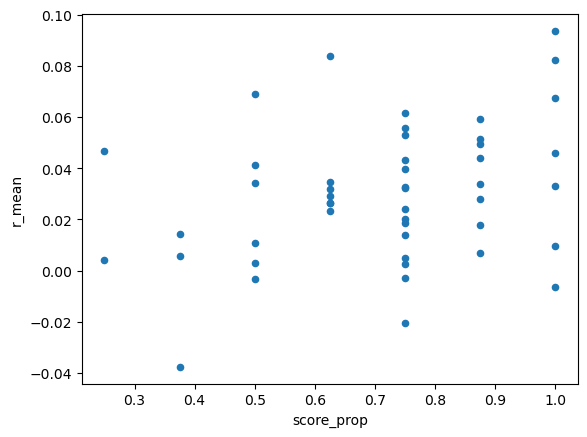

In [5]:
report.plot.scatter(x='score_prop', y='r_mean')